# QLoRA Fine-Tuning of Qwen3-8B (4-bit) — Medical Assistant

This notebook fine-tunes **Qwen3-8B** on a medical instruction dataset using
**QLoRA** (4-bit NF4 quantization + LoRA adapters), accelerated by
**Unsloth**'s patched model kernels and paired with the standard
`trl`/`datasets` stack for the training loop and data handling.

Unsloth swaps in a pre-quantized checkpoint and custom Triton kernels for
attention, RoPE, RMSNorm, and cross-entropy — the same QLoRA math as a plain
Hugging Face pipeline, but noticeably faster and lower-memory to train.

### Pipeline overview

1. Install dependencies
2. Imports
3. Configuration
4. Load the 4-bit quantized base model (Unsloth `FastLanguageModel`)
5. Apply LoRA adapters (Unsloth `get_peft_model`)
6. Load the dataset
7. Format the dataset with the Qwen chat template
8. Tokenize the dataset
9. Configure training arguments
10. Build the `SFTTrainer`
11. Train
12. Save the adapter
13. Upload the adapter to Kaggle
14. Reload the adapter
15. Run inference
16. (Optional) Merge the adapter into the base model

Run the cells top to bottom. The only things you should need to change for a
new dataset are `DATASET_NAME` and the prompt-formatting logic in the
**Format dataset** section.


## 1. Install Dependencies

Installing **Unsloth** is enough on its own — it declares matching, tested
versions of `transformers`, `trl`, `peft`, `accelerate`, and `bitsandbytes` as
its own dependencies, so pinning those separately alongside it risks a
version conflict instead of avoiding one. `datasets` and `kagglehub` are
Unsloth-independent and left unpinned. If these packages are already
installed in your environment, you can skip or comment out the install cell
below.

In [18]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install -q kagglehub

## 2. Imports

`unsloth` is imported first, before `torch`/`transformers`/`trl`, per
Unsloth's own guidance — importing it first lets it patch the relevant
model and attention classes before anything else touches them.
`FastLanguageModel` handles both 4-bit model loading and LoRA adapter
injection, replacing the separate `BitsAndBytesConfig` + `LoraConfig` +
`PeftModel` imports the plain Hugging Face pipeline needed.


In [19]:
import json
import os
from datetime import datetime

from unsloth import FastLanguageModel  # import before torch/transformers/trl so Unsloth's patches apply
import torch
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer

## 3. Configuration

Every knob you are likely to change lives in this single cell. Changing the
dataset for a new fine-tuning run should only require editing `DATASET_NAME`
(and the prompt-formatting function later, if the schema differs).


In [20]:
# --- Model ---------------------------------------------------------------
MODEL_NAME = "unsloth/Qwen3-8B-unsloth-bnb-4bit"  # Unsloth's pre-quantized 4-bit checkpoint — faster to load than quantizing Qwen/Qwen3-8B on the fly

# --- Dataset ---------------------------------------------------------------
DATASET_NAME = "medalpaca/medical_meadow_medical_flashcards"  # HF dataset id
VALIDATION_SPLIT_FRACTION = 0.02        # held out for eval; set to 0 to skip
MAX_TRAIN_SAMPLES = None                # cap dataset size for quick tests, or None

# --- LoRA / PEFT -----------------------------------------------------------
LORA_R = 16                             # rank of the low-rank update matrices
LORA_ALPHA = 32                         # scaling factor (commonly 2x r)
LORA_DROPOUT = 0.05                     # regularization on the LoRA layers
LORA_TARGET_MODULES = [                 # attention 
    "q_proj", "k_proj", "v_proj", "o_proj",]

# --- Training ---------------------------------------------------------------
OUTPUT_DIR = "./qwen3-medical-qlora"
MAX_SEQ_LENGTH = 256
NUM_TRAIN_EPOCHS = 2
LEARNING_RATE = 2e-4
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8
WARMUP_STEPS = 50                       # steps of linear LR warmup before the schedule kicks in
WEIGHT_DECAY = 0.01
LOGGING_STEPS = 50
SAVE_STEPS = 500
EVAL_STEPS = 500
RANDOM_SEED = 42

# --- Kaggle upload -----------------------------------------------------------
KAGGLE_USERNAME = "your-kaggle-username"        # your Kaggle account name
KAGGLE_DATASET_SLUG = "qwen3-medical-qlora-adapter"  # dataset slug to publish under
UPLOAD_ADAPTER_TO_KAGGLE = False                # flip to True once KAGGLE_USERNAME is set

os.makedirs(OUTPUT_DIR, exist_ok=True)
torch.manual_seed(RANDOM_SEED)

## 4. Load the 4-bit Quantized Base Model (Unsloth)

**Unsloth** replaces the manual `BitsAndBytesConfig` + `AutoModelForCausalLM`
loading with `FastLanguageModel.from_pretrained`, which:

* Loads `unsloth/Qwen3-8B-unsloth-bnb-4bit` — a checkpoint Unsloth has
  **already** quantized to 4-bit NF4 and re-uploaded, so no on-the-fly
  quantization pass is needed at load time (faster startup, lower peak RAM
  than quantizing `Qwen/Qwen3-8B` from full precision).
* Patches the model's attention and MLP layers with hand-written Triton
  kernels (fused RoPE, RMSNorm, cross-entropy, etc.) that are numerically
  equivalent to the stock Hugging Face implementation but noticeably faster
  and lower-memory during training — this patching is where the actual
  training speedup comes from, not just the pre-quantized weights.
* Still returns a standard `transformers`-compatible model + tokenizer, so
  every downstream cell (`SFTTrainer`, `generate`, `save_pretrained`, ...)
  works exactly as before.

`load_in_4bit=True` keeps QLoRA's 4-bit-frozen-base-plus-LoRA-adapter
approach. `max_seq_length` is passed in here (rather than only at
tokenization time) because Unsloth uses it to configure RoPE scaling
correctly for the context length we'll actually train at. `dtype=None` lets
Unsloth auto-detect the best compute dtype for the GPU (bfloat16 on Ampere+,
float16 otherwise) — the same logic the original notebook computed manually.


In [21]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,  # auto-detect: bfloat16 on Ampere+, float16 otherwise
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"Loaded {MODEL_NAME} in 4-bit NF4 via Unsloth, compute dtype: {compute_dtype}")

==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded unsloth/Qwen3-8B-unsloth-bnb-4bit in 4-bit NF4 via Unsloth, compute dtype: torch.float16


## 5. Apply LoRA Adapters (Unsloth)

`FastLanguageModel.get_peft_model` replaces the manual `LoraConfig` +
`SFTTrainer(peft_config=...)` pattern: it runs the kbit-training preparation
and injects the LoRA adapters directly onto the already-loaded model in one
call, using Unsloth's patched layers.

* `r=16` — rank of the LoRA update; higher values add capacity (and
  parameters) at diminishing returns. 16 is a solid default for instruction
  fine-tuning on an 8B model.
* `lora_alpha=32` — scales the LoRA update (`alpha / r` is the effective
  scaling). Using `alpha = 2 * r` is a common, well-tested default.
* `lora_dropout=0.05` — light regularization; Unsloth's fused kernels support
  dropout without giving up speed.
* `bias="none"` — do not train bias terms; the standard, memory-cheapest
  choice for LoRA.
* `target_modules` — every attention and MLP projection, the standard
  "full coverage" choice for LoRA quality.
* `use_gradient_checkpointing="unsloth"` — Unsloth's own gradient
  checkpointing implementation, which offloads activations to CPU
  asynchronously and is both faster and lower-memory than the standard
  `transformers` implementation used in the original notebook.
* `random_state=RANDOM_SEED` — makes LoRA's random initialization
  reproducible.

Because LoRA is applied here rather than inside `SFTTrainer`, the trainer in
section 10 is given the already-adapted model directly (no `peft_config`
argument).


In [22]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    target_modules=LORA_TARGET_MODULES,
    use_gradient_checkpointing="unsloth",
    random_state=RANDOM_SEED,
)

## 6. Load the Dataset

Loads the dataset from the Hugging Face Hub and creates a train/validation
split. To fine-tune on a different dataset, change `DATASET_NAME` in the
configuration cell — as long as it exposes an `instruction`/`input`/`output`
style schema (or you adjust `format_example` in the next section), nothing
else needs to change.


In [23]:
raw_dataset = load_dataset(DATASET_NAME)

# Some datasets ship only a "train" split; carve out a validation set from it.
if "validation" in raw_dataset:
    train_dataset = raw_dataset["train"]
    eval_dataset = raw_dataset["validation"]
elif VALIDATION_SPLIT_FRACTION > 0:
    split = raw_dataset["train"].train_test_split(
        test_size=VALIDATION_SPLIT_FRACTION, seed=RANDOM_SEED
    )
    train_dataset, eval_dataset = split["train"], split["test"]
else:
    train_dataset, eval_dataset = raw_dataset["train"], None

if MAX_TRAIN_SAMPLES is not None:
    train_dataset = train_dataset.select(range(min(MAX_TRAIN_SAMPLES, len(train_dataset))))

print(f"Train samples: {len(train_dataset):,}")
print(f"Eval samples: {len(eval_dataset):,}" if eval_dataset else "Eval samples: 0")
print(f"Columns: {train_dataset.column_names}")


Train samples: 33,275
Eval samples: 680
Columns: ['input', 'output', 'instruction']


## 7. Format the Dataset with the Qwen Chat Template

Instruction datasets come as flat `instruction` / `input` / `output` fields.
We convert each example into a chat-style `messages` list and let the
tokenizer's built-in `apply_chat_template` render it into the exact prompt
format Qwen3 was trained on (special tokens, role markers, etc.) — this is
more reliable than hand-writing the template ourselves.

`add_generation_prompt=False` because these are complete training examples
(prompt + answer), not open-ended prompts we want the model to continue.


In [24]:
SYSTEM_PROMPT = "You are a helpful, accurate medical assistant."

def format_example(example):
    """Convert a flat instruction/input/output row into a rendered chat string."""
    user_content = example["instruction"]
    if example.get("input"):
        user_content += f"\n\n{example['input']}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": example["output"]},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

columns_to_remove = train_dataset.column_names
train_dataset = train_dataset.map(format_example, remove_columns=columns_to_remove)
if eval_dataset is not None:
    eval_dataset = eval_dataset.map(format_example, remove_columns=columns_to_remove)

print(train_dataset[0]["text"][:500])


<|im_start|>system
You are a helpful, accurate medical assistant.<|im_end|>
<|im_start|>user
Answer this question truthfully

What is the management approach for anaphylaxis that is refractory to one dose of IM epi without respiratory failure signs?<|im_end|>
<|im_start|>assistant
<think>

</think>

Anaphylaxis that is refractory to one dose of IM epi without respiratory failure signs is managed with repeat IM epi.<|im_end|>



## 8. Tokenization

`SFTTrainer` can tokenize on the fly, but doing it explicitly here keeps the
pipeline transparent and lets us inspect sequence lengths before training.
Sequences are truncated (not padded) at this stage — padding happens
per-batch via the data collator, which is more memory-efficient than padding
every example to `MAX_SEQ_LENGTH` up front.


In [25]:
def tokenize_example(example):
    return tokenizer(example["text"], truncation=True, max_length=MAX_SEQ_LENGTH)

train_dataset = train_dataset.map(tokenize_example, remove_columns=["text"])
if eval_dataset is not None:
    eval_dataset = eval_dataset.map(tokenize_example, remove_columns=["text"])

token_lengths = [len(ids) for ids in train_dataset["input_ids"]]
print(f"Mean tokens/example: {sum(token_lengths) / len(token_lengths):.1f}")
print(f"Max tokens/example: {max(token_lengths)}")
print(f"Sequences truncated at {MAX_SEQ_LENGTH} tokens")


Map:   0%|          | 0/33275 [00:00<?, ? examples/s]

Map:   0%|          | 0/680 [00:00<?, ? examples/s]

Mean tokens/example: 125.5
Max tokens/example: 256
Sequences truncated at 256 tokens


## 9. Training Configuration

`SFTConfig` extends `transformers.TrainingArguments` with a few
SFT-specific fields. Key choices for QLoRA fine-tuning of an 8B model:

* `per_device_train_batch_size=1` with `gradient_accumulation_steps=8` —
  an effective batch size of 8 while keeping per-step activation memory low.
* `bf16`/`fp16` — mixed precision matches whatever `compute_dtype` Unsloth
  selected when loading the model.
* `optim="paged_adamw_8bit"` — an 8-bit AdamW variant with paged memory that
  is the standard optimizer choice for QLoRA; it dramatically reduces
  optimizer-state memory versus full-precision AdamW.
* `warmup_steps=50` and a cosine schedule — a short, fixed-length warmup
  followed by smooth decay is the standard recipe for LoRA fine-tuning. A
  fixed step count (rather than a ratio of total steps) keeps the warmup
  length predictable regardless of dataset size.
* `max_grad_norm=0.3` — gradient clipping to guard against the occasional
  loss spike that 4-bit training can produce.
* `save_steps`/`eval_steps` — periodic checkpointing and evaluation so
  training can be monitored and resumed.

Note: gradient checkpointing is **not** configured here — it was already
enabled via `use_gradient_checkpointing="unsloth"` when the LoRA adapters
were applied in section 5, so setting it again in `TrainingArguments` would
be redundant and would fight with Unsloth's own implementation.


In [26]:
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=0.3,
    optim="paged_adamw_8bit",
    bf16=(compute_dtype == torch.bfloat16),
    fp16=(compute_dtype == torch.float16),
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    eval_strategy="steps" if eval_dataset is not None else "no",
    eval_steps=EVAL_STEPS if eval_dataset is not None else None,
    report_to="none",
    seed=RANDOM_SEED,
    max_length=MAX_SEQ_LENGTH,
    packing=True,
)

## 10. Build the Trainer

`SFTTrainer` wraps `transformers.Trainer` with sensible defaults for
supervised fine-tuning on chat/instruction data. The model passed in here
already has LoRA adapters applied (section 5) and Unsloth's fused kernels
patched in, so no `peft_config` is passed here — doing so again would try
to wrap the model in LoRA a second time. Since we already tokenized the
dataset ourselves, we pass the pre-tokenized `input_ids` directly and let
the trainer's default data collator handle dynamic padding per batch.


In [27]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

trainable_params, total_params = trainer.model.get_nb_trainable_parameters()
print(f"Trainable params: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.3f}%)")

Unsloth: Packing train dataset:   0%|          | 0/33275 [00:00<?, ? examples/s]

Unsloth: Packing eval dataset:   0%|          | 0/680 [00:00<?, ? examples/s]

🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!
Trainable params: 15,335,424 / 8,206,070,784 (0.187%)


## 11. Train

Resumes automatically from the latest checkpoint in `OUTPUT_DIR` if one
exists, so re-running this cell after an interruption picks up where it left
off instead of restarting.


In [28]:
resume_checkpoint = None
if os.path.isdir(OUTPUT_DIR):
    checkpoints = [d for d in os.listdir(OUTPUT_DIR) if d.startswith("checkpoint-")]
    if checkpoints:
        resume_checkpoint = os.path.join(
            OUTPUT_DIR, sorted(checkpoints, key=lambda d: int(d.split("-")[-1]))[-1]
        )
        print(f"Resuming from checkpoint: {resume_checkpoint}")

try:
    train_result = trainer.train(resume_from_checkpoint=resume_checkpoint)
    print(train_result.metrics)
except torch.cuda.OutOfMemoryError:
    print(
        "CUDA out of memory. Try lowering MAX_SEQ_LENGTH, "
        "or increasing GRADIENT_ACCUMULATION_STEPS while keeping "
        "PER_DEVICE_TRAIN_BATCH_SIZE at 1."
    )
    raise


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 17,256 | Num Epochs = 2 | Total steps = 2,158
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 15,335,424 of 8,206,070,784 (0.19% trained)


Step,Training Loss,Validation Loss
500,0.652400,0.647261
1000,0.626000,0.626480
1500,0.590200,0.616635
2000,0.587700,0.613263


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


{'train_runtime': 28525.3637, 'train_samples_per_second': 1.21, 'train_steps_per_second': 0.076, 'total_flos': 3.801327085587579e+17, 'train_loss': 0.645088340531244, 'epoch': 2.0}


## 12. Save the Adapter

Saves only the small LoRA adapter weights (a few tens of MB) plus the
tokenizer — not the full 8B-parameter base model. This is the artifact you
ship and reload later.


In [29]:
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "final_adapter")

trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"Adapter and tokenizer saved to: {ADAPTER_DIR}")
print(os.listdir(ADAPTER_DIR))


Adapter and tokenizer saved to: ./qwen3-medical-qlora/final_adapter
['vocab.json', 'special_tokens_map.json', 'README.md', 'tokenizer_config.json', 'tokenizer.json', 'merges.txt', 'added_tokens.json', 'chat_template.jinja', 'adapter_config.json', 'training_args.bin', 'adapter_model.safetensors']


## 13. Upload the Adapter to Kaggle

Publishes the saved adapter directory as a private Kaggle Dataset using
[`kagglehub`](https://github.com/Kaggle/kagglehub), so it can be pulled into
other Kaggle notebooks or downloaded elsewhere without re-running training.

Requirements:

* A Kaggle account with an API token. Either place `kaggle.json` in
  `~/.kaggle/kaggle.json`, or set the `KAGGLE_USERNAME` and `KAGGLE_KEY`
  environment variables before running this cell.
* `KAGGLE_USERNAME` and `KAGGLE_DATASET_SLUG` set correctly in the
  configuration cell, and `UPLOAD_ADAPTER_TO_KAGGLE = True`.

If the dataset (`KAGGLE_USERNAME/KAGGLE_DATASET_SLUG`) does not exist yet,
`kagglehub.dataset_upload` creates it; if it already exists, it pushes a new
version.


In [30]:
if not UPLOAD_ADAPTER_TO_KAGGLE:
    print("UPLOAD_ADAPTER_TO_KAGGLE is False — skipping Kaggle upload.")
elif not (os.getenv("KAGGLE_KEY") or os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json"))):
    print(
        "No Kaggle credentials found. Set KAGGLE_USERNAME/KAGGLE_KEY env vars "
        "or place a kaggle.json file in ~/.kaggle/, then re-run this cell."
    )
else:
    import kagglehub

    kaggle_handle = f"{KAGGLE_USERNAME}/{KAGGLE_DATASET_SLUG}"
    try:
        kagglehub.dataset_upload(kaggle_handle, ADAPTER_DIR)
        print(f"Adapter uploaded: https://www.kaggle.com/datasets/{kaggle_handle}")
    except Exception as error:
        print(f"Kaggle upload failed: {error}")


UPLOAD_ADAPTER_TO_KAGGLE is False — skipping Kaggle upload.


## 14. Reload the Adapter

Demonstrates loading the adapter back from disk with Unsloth's
`FastLanguageModel.from_pretrained` — the same call as section 4, except
pointed at `ADAPTER_DIR` instead of the base model name. Unsloth reads
`adapter_config.json`, resolves the original base model, reloads it in
4-bit, and re-attaches the saved LoRA weights in one step, so no separate
`PeftModel.from_pretrained` call is needed. This is the same process you'd
use in a separate inference session, days or weeks after training.

`FastLanguageModel.for_inference()` switches the model into Unsloth's
inference-optimized mode (up to 2x faster generation) — call it once after
loading, before running any prompts through the model.


In [31]:
inference_model, inference_tokenizer = FastLanguageModel.from_pretrained(
    model_name=ADAPTER_DIR,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
)
FastLanguageModel.for_inference(inference_model)

print("Adapter reloaded successfully.")

==((====))==  Unsloth 2026.7.6: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Adapter reloaded successfully.


## 15. Inference

Runs a few medical prompts through the fine-tuned model to confirm the
adapter is loaded and producing sensible, on-domain responses.


In [32]:
def generate_response(prompt, max_new_tokens=256):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    input_ids = inference_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(inference_model.device)

    with torch.no_grad():
        output_ids = inference_model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=inference_tokenizer.pad_token_id,
        )

    generated_ids = output_ids[0][input_ids.shape[-1]:]
    return inference_tokenizer.decode(generated_ids, skip_special_tokens=True)

test_prompts = [
    "What are the common symptoms of type 2 diabetes?",
    "Explain the difference between a virus and a bacterium.",
    "What precautions should a patient take after knee replacement surgery?",
]

for prompt in test_prompts:
    print(f"Q: {prompt}")
    print(f"A: {generate_response(prompt)}")
    print("-" * 80)


Q: What are the common symptoms of type 2 diabetes?
A: <think>

</think>

Type 2 diabetes is a chronic condition that is characterized by high blood sugar levels. While some people with type 2 diabetes may not experience any symptoms, others may have a range of symptoms that can include increased thirst, frequent urination, fatigue, blurred vision, slow healing of wounds, and tingling or numbness in the hands and feet. These symptoms are often caused by the body's inability to properly use insulin, which can lead to high blood sugar levels and damage to various organs and tissues. In some cases, type 2 diabetes may also cause symptoms of hyperglycemia, such as nausea, vomiting, and abdominal pain. If you are experiencing any of these symptoms, it is important to speak with a healthcare provider for proper diagnosis and treatment.
--------------------------------------------------------------------------------
Q: Explain the difference between a virus and a bacterium.
A: <think>

</thin

## 16. (Optional) Merge the Adapter into the Base Model

Merging bakes the LoRA weights into the base model, producing a single
standalone model that no longer needs PEFT at inference time — useful for
deployment, at the cost of a full-size (non-4-bit) model on disk. This step
is optional; skip it if you only need the adapter.

Unsloth's `save_pretrained_merged(..., save_method="merged_16bit")` does the
dequantize-and-merge in one call, directly from the already-loaded
`inference_model` — no need to separately reload the base model in full
precision and merge manually.


In [33]:
MERGE_ADAPTER = True  # set to True to run this section
MERGED_MODEL_DIR = os.path.join(OUTPUT_DIR, "merged_model")

if MERGE_ADAPTER:
    inference_model.save_pretrained_merged(
        MERGED_MODEL_DIR, inference_tokenizer, save_method="merged_16bit"
    )
    print(f"Merged model saved to: {MERGED_MODEL_DIR}")
else:
    print("MERGE_ADAPTER is False — skipping merge.")

config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [01:27<00:00, 21.82s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [02:00<00:00, 30.24s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/qwen3-medical-qlora/merged_model`
Merged model saved to: ./qwen3-medical-qlora/merged_model


## 17. Additional Imports for Evaluation & Visualization

The evaluation sections below need a few extra libraries beyond what training
required: `matplotlib` for plots, `sklearn.metrics` for classification metrics,
and `Counter`/`math` for the vocabulary-bucketing and perplexity math. Kept in
one cell, imported once, right where they start being used.

Chart colors below come from a fixed, colorblind-validated categorical
palette rather than matplotlib defaults — blue for "base model" and orange
for "fine-tuned" consistently across every chart in this notebook.

In [34]:
import math
from collections import Counter

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, roc_auc_score

# Fixed categorical palette (colorblind-validated) — reused across every chart below.
COLOR_BASE = "#2a78d6"        # slot 1: blue — base model
COLOR_FINETUNED = "#eb6834"   # slot 2: orange — fine-tuned model
GRID_COLOR = "#e1e0d9"
TEXT_COLOR = "#52514e"


def style_axes(ax):
    """Apply consistent, low-ink chart chrome: no top/right spines, hairline gridlines."""
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


## 18. Training Loss Curve

`trainer.state.log_history` already contains every logged training (and, if
`eval_dataset` was provided, evaluation) loss value recorded during `trainer.train()`
in section 11 — no extra computation needed, just read and plot it. A
downward-sloping train-loss curve is the most direct evidence that LoRA
fine-tuning is actually fitting the medical dataset; a flat or rising eval-loss
curve while train-loss keeps falling would be the classic overfitting signature.


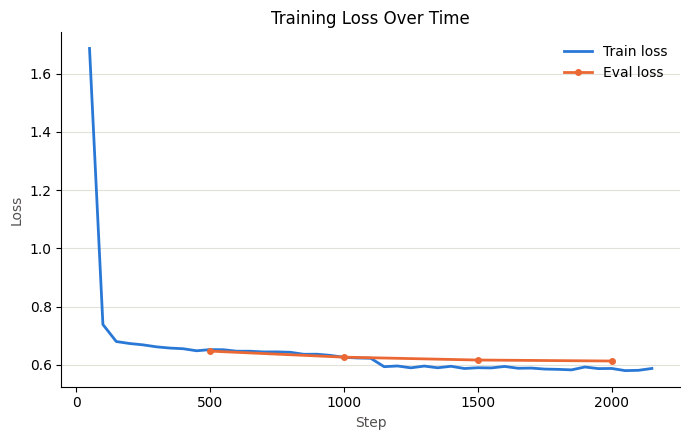

Starting train loss: 1.6862
Final train loss:    0.5877
Final eval loss:     0.6133


In [35]:
log_history = trainer.state.log_history

train_steps = [entry["step"] for entry in log_history if "loss" in entry]
train_loss = [entry["loss"] for entry in log_history if "loss" in entry]
eval_steps = [entry["step"] for entry in log_history if "eval_loss" in entry]
eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(train_steps, train_loss, color=COLOR_BASE, linewidth=2, label="Train loss")
if eval_loss:
    ax.plot(eval_steps, eval_loss, color=COLOR_FINETUNED, linewidth=2,
            marker="o", markersize=4, label="Eval loss")

ax.set_xlabel("Step", color=TEXT_COLOR)
ax.set_ylabel("Loss", color=TEXT_COLOR)
ax.set_title("Training Loss Over Time")
ax.legend(frameon=False)
style_axes(ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"), dpi=150)
plt.show()

print(f"Starting train loss: {train_loss[0]:.4f}" if train_loss else "No training loss logged.")
print(f"Final train loss:    {train_loss[-1]:.4f}" if train_loss else "")
if eval_loss:
    print(f"Final eval loss:     {eval_loss[-1]:.4f}")


## 19. Evaluation Metrics — Base Model vs Fine-Tuned Model

**Perplexity** is the metric that natively fits a causal language model: it is
just `exp(cross-entropy loss)` on held-out text, and it directly measures how
well the model predicts the medical eval set — lower is better. It requires no
adaptation and is computed below for both models.

**F1-score, recall, and ROC-AUC**, on the other hand, are classification
metrics — they need a fixed, finite set of classes, and Qwen3 predicts over a
~150K-token vocabulary at every position, which is not a meaningful "class set"
to score directly (macro-averaging over 150K mostly-unseen classes is
uninformative, and a full softmax per token position is also unnecessarily
expensive). To make these metrics meaningful and tractable, next-token
prediction is **bucketed**: the top-K most frequent tokens across the eval
set's tokenized answers each get their own class, and every other token id
falls into a single `OTHER` bucket. This turns "which token comes next" into a
genuine (K+1)-way classification problem, computed from the same forward pass
used for perplexity — no extra model calls.

**What this does and doesn't tell you:** these are *token-level*, not
*sentence-level*, metrics — they measure whether the model assigns the highest
probability to the correct next token among the buckets it's scored on, at
every position in the held-out medical answers. That is a legitimate proxy for
"did fine-tuning sharpen next-token prediction on this domain's vocabulary,"
but it is not a semantic-correctness or factual-accuracy score. Perplexity
remains the primary, unambiguous metric here; the bucketed F1/recall/ROC-AUC
numbers are a secondary, standard-classification-metric view of the same
predictions, included because they were requested.

Both models are evaluated from the single `inference_model` already loaded in
section 14: fine-tuned metrics use it as-is, and base-model metrics use
`inference_model.disable_adapter()` (a PEFT context manager) to temporarily
turn off the LoRA adapter — so the 4-bit base weights are never loaded twice.


In [36]:
def build_top_k_vocab_buckets(dataset, tokenizer, top_k=50):
    """Bucket the vocabulary into the top-k most frequent tokens plus one OTHER bucket.

    Returns the list of top token ids (bucket order) and a lookup tensor mapping
    every token id in the vocabulary to its bucket index (top_k = OTHER).
    """
    token_counts = Counter()
    for input_ids in dataset["input_ids"]:
        token_counts.update(input_ids)

    top_token_ids = [token_id for token_id, _ in token_counts.most_common(top_k)]

    token_to_bucket = torch.full((len(tokenizer),), top_k, dtype=torch.long)
    for bucket_index, token_id in enumerate(top_token_ids):
        token_to_bucket[token_id] = bucket_index

    return top_token_ids, token_to_bucket


@torch.no_grad()
def evaluate_model(model, dataset, top_token_ids, token_to_bucket, num_samples):
    """Compute perplexity and bucketed-vocab token F1/recall/ROC-AUC over a dataset sample.

    A single forward pass per example serves both perplexity (via the model's
    own labeled loss) and the bucketed classification metrics (via its logits),
    so evaluation costs one pass per example rather than two.
    """
    model.eval()
    device = model.device
    top_ids_tensor = torch.tensor(top_token_ids, device=device)
    token_to_bucket = token_to_bucket.to(device)
    num_buckets = len(top_token_ids) + 1

    total_nll, total_tokens = 0.0, 0
    true_buckets_all, pred_buckets_all, bucket_scores_all = [], [], []

    num_samples = min(num_samples, len(dataset))
    for i in range(num_samples):
        input_ids = torch.tensor(dataset[i]["input_ids"], device=device).unsqueeze(0)
        if input_ids.shape[1] < 2:
            continue

        outputs = model(input_ids=input_ids, labels=input_ids)
        num_target_tokens = input_ids.shape[1] - 1
        total_nll += outputs.loss.item() * num_target_tokens
        total_tokens += num_target_tokens

        # Position t's logits predict token t+1 — the standard causal-LM shift.
        logits = outputs.logits[0, :-1]
        true_next_tokens = input_ids[0, 1:]

        # log-softmax restricted to the top-k columns, without materializing a
        # full (seq_len x vocab_size) probability tensor.
        log_normalizer = torch.logsumexp(logits, dim=-1)
        top_k_log_probs = logits[:, top_ids_tensor] - log_normalizer.unsqueeze(-1)
        top_k_probs = top_k_log_probs.exp()
        other_prob = (1.0 - top_k_probs.sum(dim=-1)).clamp(min=0.0)
        bucket_probs = torch.cat([top_k_probs, other_prob.unsqueeze(-1)], dim=-1)

        true_buckets_all.append(token_to_bucket[true_next_tokens].cpu())
        pred_buckets_all.append(bucket_probs.argmax(dim=-1).cpu())
        bucket_scores_all.append(bucket_probs.float().cpu())

    perplexity = math.exp(total_nll / total_tokens)

    y_true = torch.cat(true_buckets_all).numpy()
    y_pred = torch.cat(pred_buckets_all).numpy()
    y_score = torch.cat(bucket_scores_all).numpy()
    bucket_labels = list(range(num_buckets))

    f1 = f1_score(y_true, y_pred, labels=bucket_labels, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, labels=bucket_labels, average="macro", zero_division=0)
    try:
        roc_auc = roc_auc_score(y_true, y_score, labels=bucket_labels, multi_class="ovr", average="macro")
    except ValueError:
        # Raised if a bucket never appears as a true label in this sample —
        # increase num_samples to fix, rather than treating this as an error.
        roc_auc = float("nan")

    return {
        "perplexity": perplexity,
        "token_f1_macro": f1,
        "token_recall_macro": recall,
        "token_roc_auc_macro": roc_auc,
        "num_eval_examples": num_samples,
        "num_eval_tokens": total_tokens,
    }


In [37]:
NUM_EVAL_SAMPLES = 50  # kept small deliberately — this is a 15GB-VRAM Colab GPU

base_metrics, finetuned_metrics = None, None

if eval_dataset is None:
    print("No eval_dataset available (VALIDATION_SPLIT_FRACTION was 0) — skipping quantitative evaluation.")
else:
    top_token_ids, token_to_bucket = build_top_k_vocab_buckets(eval_dataset, inference_tokenizer, top_k=50)

    print(f"Evaluating base model (adapter disabled) on {min(NUM_EVAL_SAMPLES, len(eval_dataset))} eval examples...")
    with inference_model.disable_adapter():
        base_metrics = evaluate_model(inference_model, eval_dataset, top_token_ids, token_to_bucket, NUM_EVAL_SAMPLES)

    print(f"Evaluating fine-tuned model on {min(NUM_EVAL_SAMPLES, len(eval_dataset))} eval examples...")
    finetuned_metrics = evaluate_model(inference_model, eval_dataset, top_token_ids, token_to_bucket, NUM_EVAL_SAMPLES)

    print(f"\n{'Metric':<24} {'Base model':>14} {'Fine-tuned':>14}")
    print("-" * 54)
    print(f"{'Perplexity':<24} {base_metrics['perplexity']:>14.3f} {finetuned_metrics['perplexity']:>14.3f}")
    print(f"{'Token F1 (macro)':<24} {base_metrics['token_f1_macro']:>14.3f} {finetuned_metrics['token_f1_macro']:>14.3f}")
    print(f"{'Token Recall (macro)':<24} {base_metrics['token_recall_macro']:>14.3f} {finetuned_metrics['token_recall_macro']:>14.3f}")
    print(f"{'Token ROC-AUC (macro)':<24} {base_metrics['token_roc_auc_macro']:>14.3f} {finetuned_metrics['token_roc_auc_macro']:>14.3f}")


Evaluating base model (adapter disabled) on 50 eval examples...
Evaluating fine-tuned model on 50 eval examples...

Metric                       Base model     Fine-tuned
------------------------------------------------------
Perplexity                       26.574          1.833
Token F1 (macro)                  0.549          0.875
Token Recall (macro)              0.555          0.871
Token ROC-AUC (macro)               nan            nan


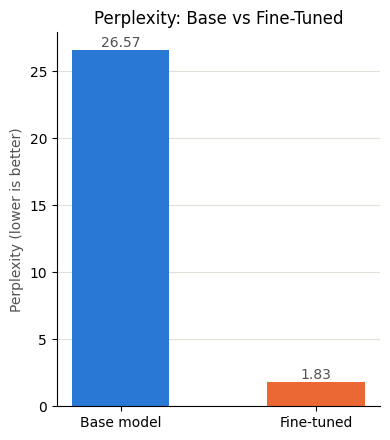

In [38]:
if base_metrics is not None:
    fig, ax = plt.subplots(figsize=(4, 4.5))
    bars = ax.bar(
        ["Base model", "Fine-tuned"],
        [base_metrics["perplexity"], finetuned_metrics["perplexity"]],
        color=[COLOR_BASE, COLOR_FINETUNED],
        width=0.5,
    )
    ax.set_ylabel("Perplexity (lower is better)", color=TEXT_COLOR)
    ax.set_title("Perplexity: Base vs Fine-Tuned")
    style_axes(ax)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.2f}", (bar.get_x() + bar.get_width() / 2, height),
                    ha="center", va="bottom", color=TEXT_COLOR)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "perplexity_comparison.png"), dpi=150)
    plt.show()


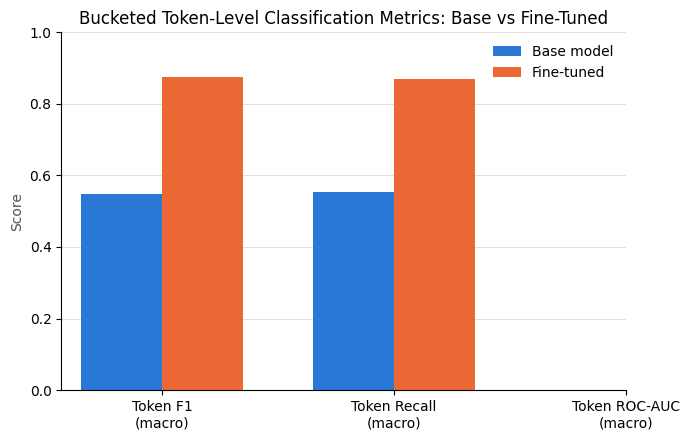

In [39]:
if base_metrics is not None:
    metric_labels = ["Token F1\n(macro)", "Token Recall\n(macro)", "Token ROC-AUC\n(macro)"]
    base_values = [base_metrics["token_f1_macro"], base_metrics["token_recall_macro"], base_metrics["token_roc_auc_macro"]]
    finetuned_values = [finetuned_metrics["token_f1_macro"], finetuned_metrics["token_recall_macro"], finetuned_metrics["token_roc_auc_macro"]]

    x = range(len(metric_labels))
    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar([i - bar_width / 2 for i in x], base_values, bar_width, label="Base model", color=COLOR_BASE)
    ax.bar([i + bar_width / 2 for i in x], finetuned_values, bar_width, label="Fine-tuned", color=COLOR_FINETUNED)

    ax.set_xticks(list(x))
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score", color=TEXT_COLOR)
    ax.set_title("Bucketed Token-Level Classification Metrics: Base vs Fine-Tuned")
    ax.legend(frameon=False)
    style_axes(ax)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "token_metrics_comparison.png"), dpi=150)
    plt.show()


## 20. Qualitative Comparison — Sample Generations

Numbers alone don't show *what changed* — this section runs the same medical
prompts (from section 15) through the base model and the fine-tuned model
side by side, so you can read the actual difference in tone, specificity, and
domain vocabulary fine-tuning produced.


In [40]:
def generate_with_model(model, tokenizer, prompt, max_new_tokens=200):
    """Generate a response from `model`, reusing the same chat-template + sampling setup as section 15."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )

    return tokenizer.decode(output_ids[0][input_ids.shape[-1]:], skip_special_tokens=True)


qualitative_comparison = []
for prompt in test_prompts:
    with inference_model.disable_adapter():
        base_answer = generate_with_model(inference_model, inference_tokenizer, prompt)
    finetuned_answer = generate_with_model(inference_model, inference_tokenizer, prompt)

    qualitative_comparison.append({"prompt": prompt, "base_answer": base_answer, "finetuned_answer": finetuned_answer})

    print(f"Q: {prompt}")
    print(f"  [Base]        {base_answer}")
    print(f"  [Fine-tuned]  {finetuned_answer}")
    print("-" * 80)


Q: What are the common symptoms of type 2 diabetes?
  [Base]        <think>
Okay, the user is asking about the common symptoms of type 2 diabetes. I need to make sure I cover all the key points without missing anything important. Let me start by recalling the main symptoms. Frequent urination is a big one, especially during the day. That's because high blood sugar leads to the kidneys trying to remove excess glucose, which increases urine production.

Then there's increased thirst. Since the body is losing so much water through frequent urination, the person feels thirsty more often. Fatigue is another symptom. High blood sugar can make the cells less efficient at using glucose for energy, leading to tiredness.

Weight gain or unexplained weight loss might be a point. Wait, actually, some people with type 2 diabetes might gain weight, especially around the abdomen, while others might lose weight unintentionally. I should mention both possibilities but clarify that weight gain is more c

## 21. Save Evaluation Report

Persists the quantitative comparison, the derived deltas, and the qualitative
generations to `evaluation_report.json` alongside the adapter — so the
evaluation is reproducible evidence, not just console output that disappears
when the runtime resets.


In [41]:
evaluation_report = {
    "base_model": base_metrics,
    "fine_tuned_model": finetuned_metrics,
    "qualitative_comparison": qualitative_comparison,
}

if base_metrics is not None:
    evaluation_report["improvement"] = {
        "perplexity_reduction_pct": 100 * (base_metrics["perplexity"] - finetuned_metrics["perplexity"]) / base_metrics["perplexity"],
        "token_f1_delta": finetuned_metrics["token_f1_macro"] - base_metrics["token_f1_macro"],
        "token_recall_delta": finetuned_metrics["token_recall_macro"] - base_metrics["token_recall_macro"],
        "token_roc_auc_delta": finetuned_metrics["token_roc_auc_macro"] - base_metrics["token_roc_auc_macro"],
    }

report_path = os.path.join(OUTPUT_DIR, "evaluation_report.json")
with open(report_path, "w") as f:
    json.dump(evaluation_report, f, indent=2)

print(f"Evaluation report saved to: {report_path}")
if base_metrics is not None:
    print(json.dumps(evaluation_report["improvement"], indent=2))


Evaluation report saved to: ./qwen3-medical-qlora/evaluation_report.json
{
  "perplexity_reduction_pct": 93.10170435318983,
  "token_f1_delta": 0.32614815473753334,
  "token_recall_delta": 0.3161484546208365,
  "token_roc_auc_delta": NaN
}
